# Introduction to plotting with Matplotlib

`Matplotlib` is the standard plotting library of the scientific Python ecosystem, and it is used in
all the notebooks of this course to visualise data and results. We only need its `pyplot` interface,
traditionally imported as `plt`, and a small number of functions.

The data to be plotted are almost always NumPy arrays, so this notebook assumes the material of
*Introduction to NumPy*.

Reference: online [documentation](https://matplotlib.org/stable/index.html) and
[gallery](https://matplotlib.org/stable/gallery/index.html) of examples.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Line plots

`plt.plot(x, y)` draws a line through the points of coordinates `x` and `y`, which are usually two
arrays of the same length. A figure is built by calling several functions in sequence: they all act on
the *current* figure, which is finally displayed by `plt.show()`.

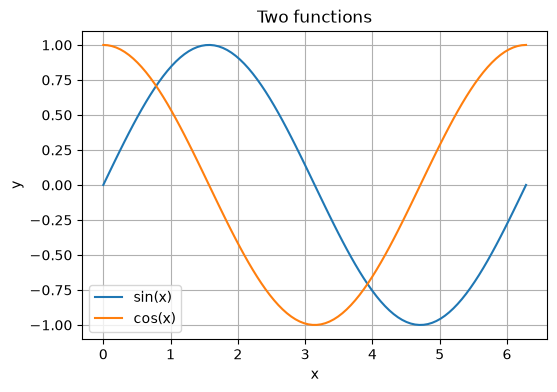

In [2]:
x = np.linspace(0., 2*np.pi, 100)

plt.figure(figsize=(6,4))                      # a new figure, size in inches
plt.plot(x, np.sin(x), label="sin(x)")
plt.plot(x, np.cos(x), label="cos(x)")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Two functions")
plt.legend()          # draws the legend, using the "label" given to each curve
plt.grid(True)
plt.show()

Note that a "curve" is just a dense sequence of segments: with too few points the plot looks
angular. The number of points of the grid is therefore a choice of the *plot*, not of the physics.

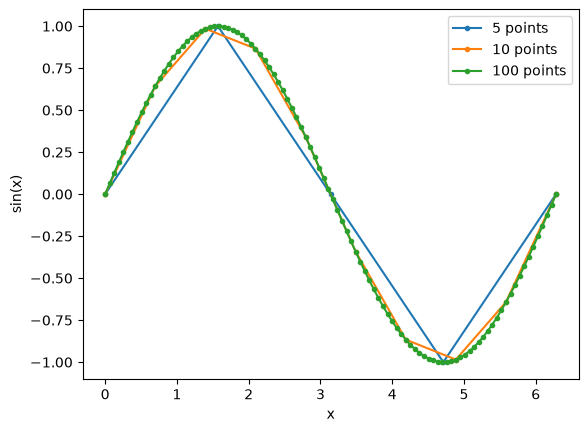

In [3]:
for n_points in [5, 10, 100]:
    x = np.linspace(0., 2*np.pi, n_points)
    plt.plot(x, np.sin(x), marker=".", label=f"{n_points} points")

plt.xlabel("x")
plt.ylabel("sin(x)")
plt.legend()
plt.show()

### Colours, line styles and markers

The third (optional) argument of `plot` is a compact *format string* combining colour, marker and
line style, e.g. `'ro--'` means red, circular markers, dashed line. The same can be expressed with the
explicit keywords `color`, `marker`, `linestyle` and `linewidth`, which are easier to read.

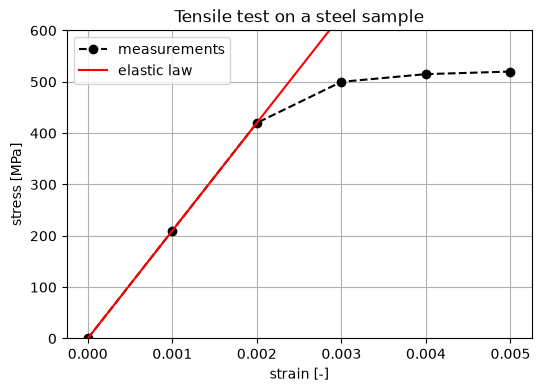

In [4]:
strain = np.array([0., 0.001, 0.002, 0.003, 0.004, 0.005])
stress = np.array([0., 210., 420., 500., 515., 520.])   # MPa

plt.figure(figsize=(6,4))
# Compact style: black circles joined by a dashed line
plt.plot(strain, stress, 'ko--', label="measurements")
# The same options, written explicitly
plt.plot(strain, 210e3*strain, color="red", linestyle="-", linewidth=1.5, label="elastic law")

plt.xlabel("strain [-]")
plt.ylabel("stress [MPa]")
plt.title("Tensile test on a steel sample")
plt.ylim(0., 600.)      # limits of the vertical axis
plt.legend()
plt.grid(True)
plt.show()

## Scatter plots

`plt.scatter()` draws points without joining them, which is the right choice when the data are
*samples* rather than a function evaluated on a grid. The size and the colour of the markers are
controlled by the arguments `s` and `c`.

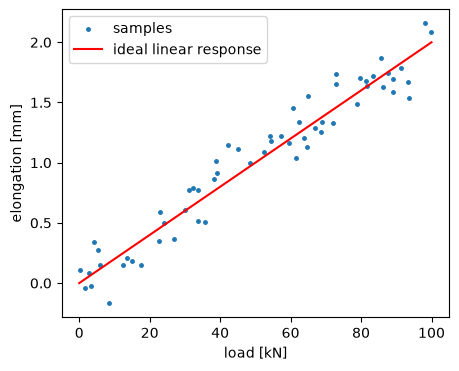

In [5]:
rng = np.random.default_rng(seed=0)

# Synthetic measurements: a linear trend plus some noise
load = rng.uniform(0., 100., 60)              # kN
elongation = 0.02*load + rng.normal(0., 0.15, 60)   # mm

plt.figure(figsize=(5,4))
plt.scatter(load, elongation, s=25, c="tab:blue", marker=".", label="samples")
plt.plot([0., 100.], [0., 2.], color="red", label="ideal linear response")
plt.xlabel("load [kN]")
plt.ylabel("elongation [mm]")
plt.legend()
plt.show()

## Several plots in the same figure

`plt.subplots(n_rows, n_cols)` creates a grid of axes and returns the figure and an array of axes.
Each axis offers the same functions as `plt`, with the prefix `set_` for the labels and the title.

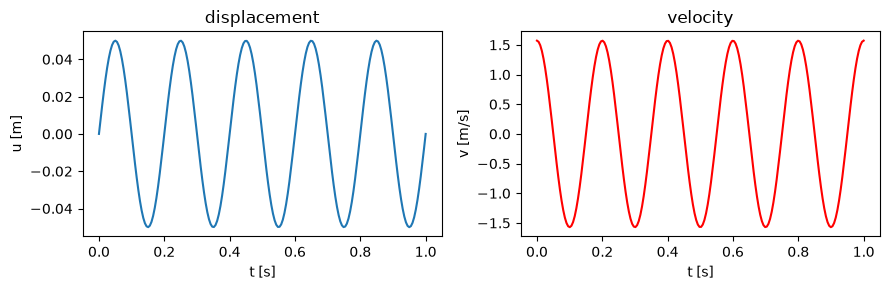

In [6]:
t = np.linspace(0., 1., 200)
displacement = 0.05*np.sin(2*np.pi*5*t)          # m
velocity = 0.05*2*np.pi*5*np.cos(2*np.pi*5*t)    # m/s

fig, axes = plt.subplots(1, 2, figsize=(9,3))

axes[0].plot(t, displacement)
axes[0].set_title("displacement")
axes[0].set_xlabel("t [s]")
axes[0].set_ylabel("u [m]")

axes[1].plot(t, velocity, color="red")
axes[1].set_title("velocity")
axes[1].set_xlabel("t [s]")
axes[1].set_ylabel("v [m/s]")

plt.tight_layout()   # avoids overlapping labels
plt.show()

## Logarithmic axes

Quantities spanning several orders of magnitude are plotted on logarithmic axes: `plt.semilogy`
(logarithmic vertical axis), `plt.semilogx` and `plt.loglog` (both axes). A typical example in
mechanical engineering is the S-N (Wohler) curve, which relates the stress amplitude of a fatigue test
to the number of cycles to failure.

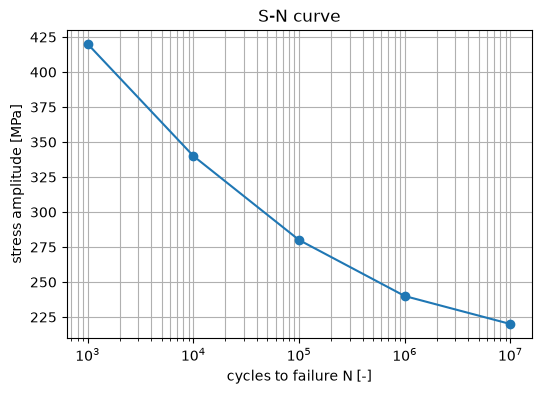

In [7]:
cycles = np.array([1e3, 1e4, 1e5, 1e6, 1e7])
amplitude = np.array([420., 340., 280., 240., 220.])   # MPa

plt.figure(figsize=(6,4))
plt.semilogx(cycles, amplitude, 'o-')
plt.xlabel("cycles to failure N [-]")
plt.ylabel("stress amplitude [MPa]")
plt.title("S-N curve")
plt.grid(True, which="both")   # a grid also on the intermediate (minor) ticks
plt.show()

## Error bars

Experimental points usually carry an uncertainty, which is displayed with `plt.errorbar()`.

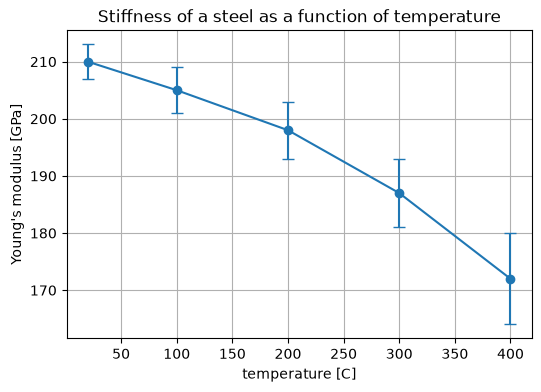

In [8]:
temperature = np.array([20., 100., 200., 300., 400.])       # C
modulus = np.array([210., 205., 198., 187., 172.])         # GPa
uncertainty = np.array([3., 4., 5., 6., 8.])               # GPa

plt.figure(figsize=(6,4))
plt.errorbar(temperature, modulus, yerr=uncertainty, fmt='o-', capsize=4)
plt.xlabel("temperature [C]")
plt.ylabel("Young's modulus [GPa]")
plt.title("Stiffness of a steel as a function of temperature")
plt.grid(True)
plt.show()

## Histograms

`plt.hist()` shows how the values of a sample are distributed, which is the first thing to look at
when inspecting a set of measurements.

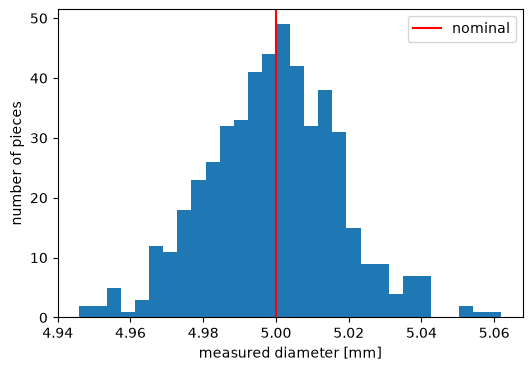

In [9]:
rng = np.random.default_rng(seed=1)
diameters = rng.normal(5.0, 0.02, 500)   # mm, nominal diameter 5 mm

plt.figure(figsize=(6,4))
plt.hist(diameters, bins=30)
plt.axvline(5.0, color="red", label="nominal")   # a vertical line
plt.xlabel("measured diameter [mm]")
plt.ylabel("number of pieces")
plt.legend()
plt.show()

## Saving a figure

`plt.savefig()` writes the current figure to a file, in the format deduced from the extension
(`.png`, `.pdf`, ...). It must be called **before** `plt.show()`, which empties the current figure.
The `dpi` argument controls the resolution of the raster formats, while `bbox_inches="tight"` trims the
white border.

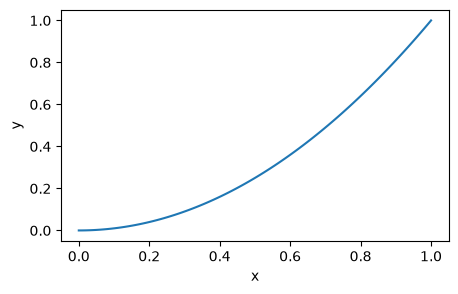

In [10]:
x = np.linspace(0., 1., 100)

plt.figure(figsize=(5,3))
plt.plot(x, x**2)
plt.xlabel("x")
plt.ylabel("y")
plt.savefig("parabola.png", dpi=150, bbox_inches="tight")   # written in the notebook folder
plt.show()

**Now you try.** A cantilever beam of length $L = 2$ m, loaded by a force $F = 1000$ N at its free
end, has deflection
$$v(x) = -\frac{F x^2}{6EI}(3L - x),$$
with $E = 210$ GPa and $I = 8\cdot10^{-6}$ m$^4$.

1. Build a grid `x` of $100$ points between $0$ and $L$ and compute `v`.
2. Plot the deflection in mm as a function of $x$, with axis labels, a title and a grid.
3. Add, on the same figure, the deflection obtained by doubling the load, with a dashed line and a legend.
4. Mark the value at the free end with `plt.scatter` and print it with an f-string.

In [11]:
L = 2.       # m
F = 1000.    # N
E = 210e9    # Pa
I = 8e-6     # m^4

# Your code here

*Solution:*

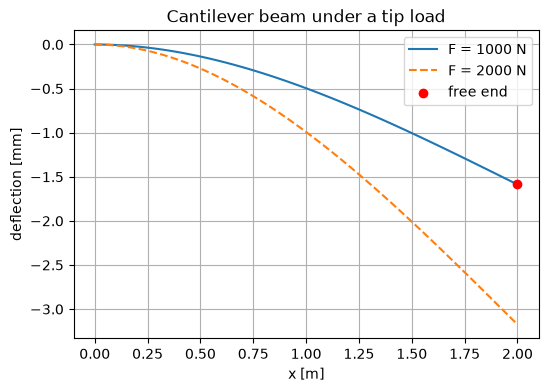

Deflection at the free end: -1.59 mm


In [12]:
L = 2.       # m
F = 1000.    # N
E = 210e9    # Pa
I = 8e-6     # m^4

# 1. Grid and deflection (vectorized: no loop is needed)
x = np.linspace(0., L, 100)
v = -F*x**2*(3*L - x)/(6*E*I)
v_double = -2*F*x**2*(3*L - x)/(6*E*I)

# 2. and 3. The deflection is converted to mm (1 m = 1000 mm)
plt.figure(figsize=(6,4))
plt.plot(x, 1000*v, label="F = 1000 N")
plt.plot(x, 1000*v_double, '--', label="F = 2000 N")

# 4. The value at the free end is the last element of the array
plt.scatter([L], [1000*v[-1]], color="red", zorder=3, label="free end")

plt.xlabel("x [m]")
plt.ylabel("deflection [mm]")
plt.title("Cantilever beam under a tip load")
plt.legend()
plt.grid(True)
plt.show()

print(f"Deflection at the free end: {1000*v[-1]:.2f} mm")